In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [7]:
df = pd.read_csv('personality_datasert.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [8]:
print(df.shape)
print(df.isna().sum())
print(df.dtypes)

(2900, 8)
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64
Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object


In [9]:
# remove dupes
df = df.drop_duplicates()


# one hot encode cat values
cat_cols = df.select_dtypes(include = ['object']).columns
df_encoded = pd.get_dummies(df, columns = cat_cols, drop_first = True)

df_encoded.head()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Stage_fear_Yes,Drained_after_socializing_Yes,Personality_Introvert
0,4.0,4.0,6.0,13.0,5.0,False,False,False
1,9.0,0.0,0.0,0.0,3.0,True,True,True
2,9.0,1.0,2.0,5.0,2.0,True,True,True
3,0.0,6.0,7.0,14.0,8.0,False,False,False
4,3.0,9.0,4.0,8.0,5.0,False,False,False


In [11]:
#separate features and target
features = df_encoded.drop('Personality_Introvert', axis = 1)
labels = df_encoded['Personality_Introvert']

In [12]:
def eval(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    conf = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"Accucary of {model_name}: {acc:.3f}")
    print("Classification Report: \n", report)

    plt.figure(figsize = (6,4))
    sns.heatmap(conf, annot = True, fmt = 'd', cmap = 'viridis',
                xticklabels = ['Introvert', 'Extrovert'],
                yticklabels = ['Introvert', 'Extrovert'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [13]:
#create the train test splits
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size= 0.2,
    random_state = 42
)
#normalize the data via a standard scaler (though not that necessary here)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
# load up classifiers

classifier1 = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)
classifier2 = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)


In [15]:
classifier1.fit(X_train, y_train)
classifier2.fit(X_train, y_train)

y_pred1 = classifier1.predict(X_test)
y_pred2 = classifier2.predict(X_test)

Accucary of Gradient Boosting Classifier: 0.906
Classification Report: 
               precision    recall  f1-score   support

       False       0.93      0.90      0.91       279
        True       0.88      0.92      0.90       221

    accuracy                           0.91       500
   macro avg       0.90      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



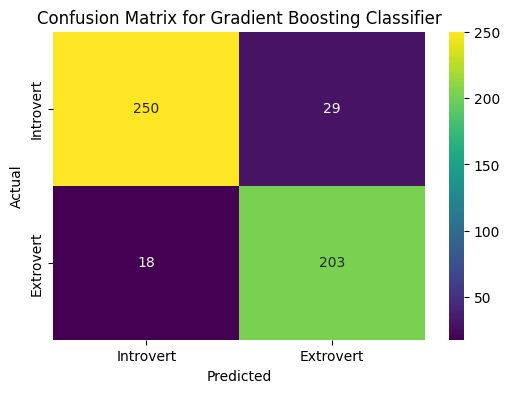

Accucary of Logistic Regression: 0.904
Classification Report: 
               precision    recall  f1-score   support

       False       0.93      0.90      0.91       279
        True       0.88      0.91      0.89       221

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



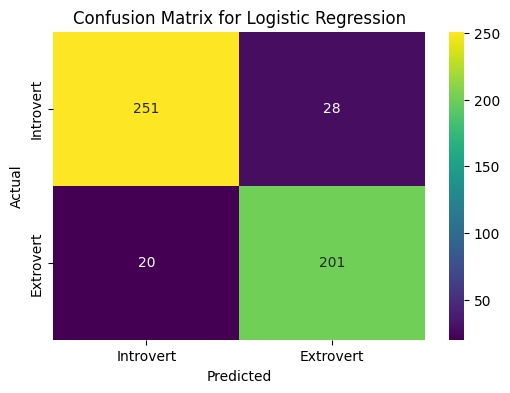

In [16]:
#evals
eval(y_test, y_pred1, "Gradient Boosting Classifier")
eval(y_test, y_pred2, "Logistic Regression")